# 💉 Gemma-4 QLoRA Training + Inference & Evaluation
## VaccineNLP Thesis — Kiến trúc Gemma-4 Teacher (XAI)

**Tác giả:** Kim Mạnh Hưng (2211090016) · Đinh Lê Quỳnh Phương (2211090031)  
**Người hướng dẫn:** TS. Trần Lâm Quân  
**Trường:** Đại học Y tế Công cộng (HUPH)  
**Môi trường:** Kaggle · GPU T4 x2  
**Framework:** Unsloth

### 📋 Workflow notebook (2 Phase):
- **Phase A** — QLoRA Fine-tuning: Huấn luyện Gemma-4 4B với dữ liệu Silver
- **Phase B** — Inference & Evaluation: Đánh giá trên Gold Test Set (186 mẫu)

> ✅ **Notebook này tương thích với chế độ "Save & run all" của Kaggle.**
> Toàn bộ notebook chạy trên **2x T4 GPU (16GB)** — không cần restart thủ công.


In [1]:
# [CELL 1] Cài đặt Unsloth & Xử lý Numpy
# ✅ FIX: Di chuyển pip install lên đầu tiên để tránh lỗi mid-session upgrade

import os, subprocess, sys

def run_silent(cmd):
    print(f"🏃 Running: {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"⚠️  STDERR: {result.stderr[-300:]}")
    return result.returncode

# 1. Gỡ cài đặt numpy cũ nếu cần hoặc cài đè ngay lập tức
# Unsloth cần numpy>=2.0. Kaggle có 2.0.2. Chúng ta sẽ cài bản pinned để tránh upgrade lên bản dev/beta
print("📦 Cài đặt Unsloth [Kaggle-new]...")
# Sử dụng git install để có bản mới nhất fix lỗi Gemma-4
run_silent('pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git" --quiet')

# 2. Kiểm tra lại numpy
try:
    import numpy as np
    print(f"✅ Numpy version: {np.__version__}")
except RuntimeError as e:
    print(f"❌ Lỗi Numpy: {e}")
    print("   → Đang thử fix bằng cách reload...")
    import importlib
    importlib.reload(np)

# 3. Kiểm tra GPU
print("🖥️  GPU Info:")
subprocess.run("nvidia-smi -L", shell=True)

try:
    from unsloth import FastModel
    print("✅ Unsloth FastModel import OK")
except ImportError as e:
    print(f"❌ Import lỗi: {e}")


📦 Cài đặt Unsloth [Kaggle-new]...
🏃 Running: pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git" --quiet
✅ Numpy version: 2.0.2
🖥️  GPU Info:
GPU 0: Tesla T4 (UUID: GPU-cca7c108-cafb-93e4-8cdf-fb93d9e57428)
GPU 1: Tesla T4 (UUID: GPU-87efa953-4edf-36f4-b8d9-32fbc4c8a1df)
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Unsloth FastModel import OK


---
## ⚙️ Phase A — QLoRA Fine-tuning
### Bước 1: Imports & Kiểm tra GPU


In [2]:
# [CELL 2] Imports & GPU diagnostics
import os, gc, json, glob, datetime, shutil
import torch
from huggingface_hub import login, HfApi
from datasets import load_dataset
from unsloth import FastModel
from unsloth.chat_templates import get_chat_template, train_on_responses_only
from trl import SFTTrainer, SFTConfig
from IPython.display import FileLink, display

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# GPU info
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    total_gb = props.total_memory / 1e9
    print(f"🖥️  GPU: {props.name}")
    print(f"💾 VRAM: {total_gb:.1f} GB")
    print(f"🔢 CUDA: {torch.version.cuda}")
    print(f"⚡ BF16: {'✅' if torch.cuda.is_bf16_supported() else '❌ (dùng FP16)'}")
    if total_gb < 14:
        print("⚠️  CẢNH BÁO: VRAM < 14GB — có thể OOM khi train")
else:
    raise RuntimeError("❌ Không tìm thấy GPU — Vui lòng bật GPU T4 trong Kaggle Settings")

🖥️  GPU: Tesla T4
💾 VRAM: 15.6 GB
🔢 CUDA: 12.8
⚡ BF16: ❌ (dùng FP16)


### Bước 2: Cấu hình tập trung

In [3]:
# [CELL 3] CẤU HÌNH TẬP TRUNG — Chỉnh sửa tại đây, KHÔNG sửa ở các cell khác

# --- Paths ---
try:
    TRAIN_PATH = glob.glob("/kaggle/input/**/train_v2_seg.jsonl", recursive=True)[0]
    TEST_PATH  = glob.glob("/kaggle/input/**/benchmark_test_set.jsonl", recursive=True)[0]
except IndexError:
    TRAIN_PATH = "/kaggle/input/vaccinenlp-clean-data/05_model_ready/train_v2_seg.jsonl"
    TEST_PATH  = "/kaggle/input/vaccinenlp-clean-data/03_processed/benchmark_test_set.jsonl"

MODELS_SAVE_DIR = "/kaggle/working/gemma_qlora_xai"
INFERENCE_OUT   = "/kaggle/working/gemma_inference_results_v2.jsonl"
RESULTS_JSON    = "/kaggle/working/gemma_v2_results.json"   # ✅ FIX: tên file chuẩn dự án
HF_REPO_ID      = "hung2903/gemma-4-E4B-unsloth-vaccine-xai"

# --- Model ---
BASE_MODEL   = "unsloth/gemma-4-E4B-it"
MAX_SEQ_LEN  = 1024
LOAD_IN_4BIT = True

# --- LoRA ---
LORA_R       = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.0

# --- Training ---
BATCH_SIZE   = 2
GRAD_ACCUM   = 4
WARMUP_STEPS = 10
TRAIN_EPOCHS = 2
LEARNING_RATE= 2e-4
WEIGHT_DECAY = 0.01
LR_SCHEDULER = "cosine"
SEED         = 42

# ── Label Maps ────────────────────────────────────────────────────────────────
# QUAN TRỌNG: MISINFO_MAP và SENTIMENT_MAP phải khớp CHÍNH XÁC với labels dùng
# trong training (format_prompt). Thay đổi ở đây = phải retrain.
#
# Ánh xạ: standardized_ids (HC index) → label text dùng khi training
#   HC misinfo: 0=Không liên quan, 1=Tin giả, 2=Chính xác
#   HC sentiment: 0=Tiêu cực, 1=Trung tính, 2=Tích cực
MISINFO_MAP   = {0: 'Tin chuẩn', 1: 'Tin giả/Sai lệch', 2: 'Không liên quan'}
STANCE_MAP    = {0: 'Ủng hộ',    1: 'Phản đối',          2: 'Trung lập',        3: 'Không rõ'}
SENTIMENT_MAP = {0: 'Tiêu cực',  1: 'Tích cực',          2: 'Trung lập'}

# HC display names (cho confusion matrix & comparison table)
HC_MISINFO    = {0: 'Không liên quan', 1: 'Tin giả', 2: 'Chính xác'}
HC_STANCE     = {0: 'Ủng hộ',         1: 'Phản đối', 2: 'Trung lập',  3: 'Không rõ'}
HC_SENTIMENT  = {0: 'Tiêu cực',       1: 'Trung tính', 2: 'Tích cực'}

os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
print("✅ Config loaded")
print(f"   Train       : {TRAIN_PATH}")
print(f"   Test (Gold) : {TEST_PATH}")
print(f"   Output      : {MODELS_SAVE_DIR}")
print(f"   Results JSON: {RESULTS_JSON}")
print()
print("⚠️  MISINFO_MAP (training labels, KHÔNG phải HC labels):")
for k,v in MISINFO_MAP.items():
    print(f"     idx {k} → '{v}' (HC: {HC_MISINFO[k]})")
print()
print("⚠️  SENTIMENT_MAP (training labels, KHÔNG phải HC labels):")
for k,v in SENTIMENT_MAP.items():
    print(f"     idx {k} → '{v}' (HC: {HC_SENTIMENT[k]})")


✅ Config loaded
   Train       : /kaggle/input/datasets/mnhhngkim/vaccinenlp-clean-data/05_model_ready/train_v2_seg.jsonl
   Test (Gold) : /kaggle/input/datasets/mnhhngkim/vaccinenlp-clean-data/03_processed/benchmark_test_set.jsonl
   Output      : /kaggle/working/gemma_qlora_xai
   Results JSON: /kaggle/working/gemma_v2_results.json

⚠️  MISINFO_MAP (training labels, KHÔNG phải HC labels):
     idx 0 → 'Tin chuẩn' (HC: Không liên quan)
     idx 1 → 'Tin giả/Sai lệch' (HC: Tin giả)
     idx 2 → 'Không liên quan' (HC: Chính xác)

⚠️  SENTIMENT_MAP (training labels, KHÔNG phải HC labels):
     idx 0 → 'Tiêu cực' (HC: Tiêu cực)
     idx 1 → 'Tích cực' (HC: Trung tính)
     idx 2 → 'Trung lập' (HC: Tích cực)


### Bước 3: Load Gemma-4 + LoRA Config

In [4]:
# [CELL 4] Load Gemma-4 E4B + LoRA adapter
model, tokenizer = FastModel.from_pretrained(
    model_name     = BASE_MODEL,
    max_seq_length = MAX_SEQ_LEN,
    dtype          = None,
    load_in_4bit   = LOAD_IN_4BIT,
)

model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r                          = LORA_R,
    lora_alpha                 = LORA_ALPHA,
    lora_dropout               = LORA_DROPOUT,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",
    random_state               = SEED,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model loaded: {BASE_MODEL}")
print(f"   Total params    : {total_params/1e6:.1f}M")
print(f"   Trainable params: {trainable_params/1e6:.1f}M ({100*trainable_params/total_params:.2f}%)")

==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/203 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

✅ Model loaded: unsloth/gemma-4-E4B-it
   Total params    : 6335.5M
   Trainable params: 36.7M (0.58%)


### Bước 4: Chuẩn bị Dataset & Format Prompt

In [5]:
# [CELL 5] Dataset preparation + prompt formatting
tokenizer = get_chat_template(tokenizer, chat_template="gemma-4")

def format_prompt(row):
    """Chuyển row JSONL → conversation format cho Gemma-4 (XAI pattern)."""
    text      = row.get('text_cleaned') or row.get('text') or ''
    reasoning = row.get('llm_reasoning', 'Phân tích dựa trên ngữ cảnh.')
    ids       = row.get('standardized_ids') or [0, 2, 1]

    misinfo_label = MISINFO_MAP.get(ids[0], 'Không liên quan')
    stance_label  = STANCE_MAP.get(ids[1], 'Không rõ')
    senti_label   = SENTIMENT_MAP.get(ids[2], 'Trung tính')

    convo = [
        {
            "role": "user",
            "content": (
                f"Phân tích nội dung sau về vaccine:\n\n\"{text}\"\n\n"
                "Hãy:\n"
                "1. Lý luận từng bước về nội dung\n"
                "2. Phân loại theo 3 chiều:\n"
                "   - Misinformation: Tin chuẩn / Tin giả/Sai lệch / Không liên quan\n"
                "   - Stance: Ủng hộ / Phản đối / Trung lập / Không rõ\n"
                "   - Sentiment: Tiêu cực / Tích cực / Trung lập"
            )
        },
        {
            "role": "assistant",
            "content": (
                f"Lý luận:\n{reasoning}\n\n"
                f"Kết quả:\n"
                f"- Misinformation: {misinfo_label}\n"
                f"- Stance: {stance_label}\n"
                f"- Sentiment: {senti_label}"
            )
        }
    ]
    return tokenizer.apply_chat_template(convo, tokenize=False)

# Load dataset
raw_ds = load_dataset("json", data_files={"train": TRAIN_PATH}, split="train")
split  = raw_ds.train_test_split(test_size=0.1, seed=SEED)
train_ds = split["train"].map(lambda r: {"text": format_prompt(r)}, num_proc=2)
eval_ds  = split["test"].map(lambda r: {"text": format_prompt(r)}, num_proc=2)

print(f"✅ Dataset ready — Train: {len(train_ds)}, Eval: {len(eval_ds)}")


Generating train split: 0 examples [00:00, ? examples/s]

Map (num_proc=2):   0%|          | 0/1503 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/167 [00:00<?, ? examples/s]

✅ Dataset ready — Train: 1503, Eval: 167


### Bước 5: Huấn luyện QLoRA

In [6]:
# [CELL 6] SFTTrainer + train_on_responses_only
trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_ds,
    eval_dataset  = eval_ds,
    args = SFTConfig(
        output_dir                  = MODELS_SAVE_DIR,
        dataset_text_field          = "text",
        max_length                  = MAX_SEQ_LEN,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = 1,
        gradient_accumulation_steps = GRAD_ACCUM,
        eval_accumulation_steps     = 1,
        warmup_steps                = WARMUP_STEPS,
        num_train_epochs            = TRAIN_EPOCHS,
        learning_rate               = LEARNING_RATE,
        weight_decay                = WEIGHT_DECAY,
        lr_scheduler_type           = LR_SCHEDULER,
        fp16                        = not torch.cuda.is_bf16_supported(),
        bf16                        = torch.cuda.is_bf16_supported(),
        logging_steps               = 10,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        seed                        = SEED,
        report_to                   = "none",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|turn>user\n",
    response_part    = "<|turn>model\n",
)

print("🚀 Bắt đầu huấn luyện...")
train_result = trainer.train()
print(f"✅ Huấn luyện hoàn tất!")
print(f"   Loss cuối: {train_result.training_loss:.4f}")

# Lưu model
trainer.save_model(f"{MODELS_SAVE_DIR}/final_model")
tokenizer.save_pretrained(f"{MODELS_SAVE_DIR}/final_model")
print(f"✅ Model đã lưu: {MODELS_SAVE_DIR}/final_model")

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1503 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/167 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/1503 [00:00<?, ? examples/s]

Filter (num_proc=8):   0%|          | 0/1503 [00:00<?, ? examples/s]

Unsloth: Removed 58 out of 1503 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.


...

Epoch,Training Loss,Validation Loss
1,0.009348,2.292397
2,0.004729,2.226011


Unsloth: Not an error, but Gemma4ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma_qlora_xai/checkpoint-181/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma_qlora_xai/checkpoint-362/tokenizer_config.json.


✅ Huấn luyện hoàn tất!
   Loss cuối: 0.0799


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma_qlora_xai/final_model/tokenizer_config.json.


✅ Model đã lưu: /kaggle/working/gemma_qlora_xai/final_model


### Bước 6b: 📈 Training Curves — QLoRA Phase A

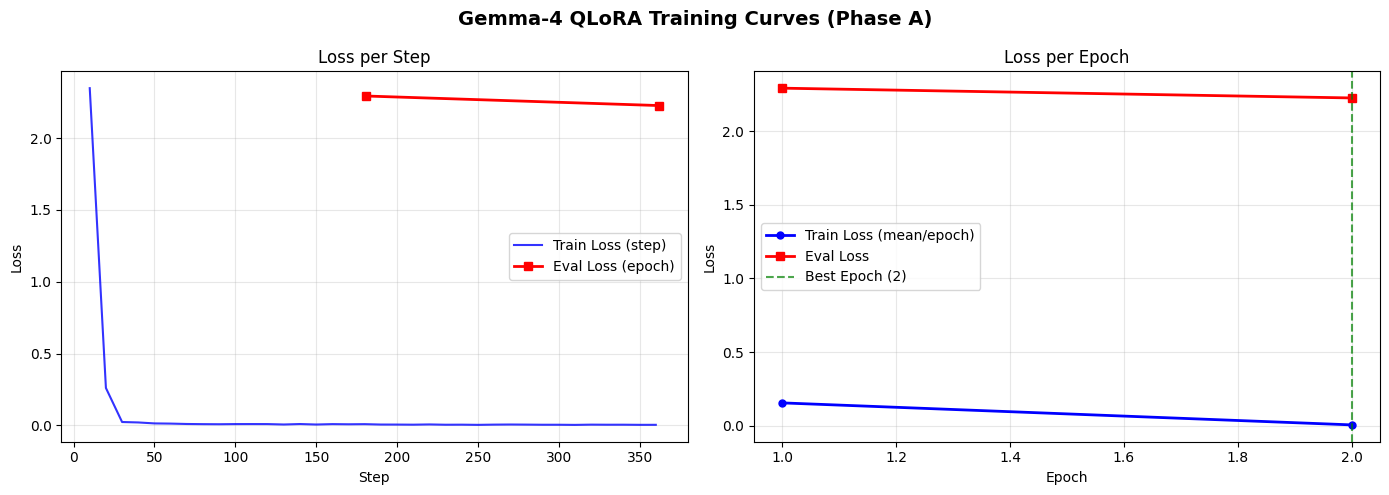

Saved: /kaggle/working/gemma_qlora_xai/training_curves.png
Total steps: 362 | Final train loss: 0.0047
Best eval loss: 2.2260 at step 2.2923965454101562


In [7]:
# [CELL 6b] Training Curves — SFTTrainer log_history
import matplotlib.pyplot as plt, numpy as np

log_history = trainer.state.log_history
train_logs = [(x["step"], x["loss"])      for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [(x["step"], x["eval_loss"]) for x in log_history if "eval_loss" in x]

if not train_logs:
    print("No training logs found")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Gemma-4 QLoRA Training Curves (Phase A)", fontsize=14, fontweight="bold")

    train_steps, train_loss = zip(*train_logs)
    ax = axes[0]
    ax.plot(train_steps, train_loss, "b-", lw=1.5, label="Train Loss (step)", alpha=0.8)
    if eval_logs:
        es, el = zip(*eval_logs)
        ax.plot(es, el, "r-s", lw=2, ms=6, label="Eval Loss (epoch)")
    ax.set(xlabel="Step", ylabel="Loss", title="Loss per Step")
    ax.legend(); ax.grid(True, alpha=0.3)

    total_steps  = trainer.state.max_steps
    steps_per_ep = max(1, total_steps // TRAIN_EPOCHS)
    epoch_means, epoch_nums = [], []
    for ep in range(TRAIN_EPOCHS):
        ep_losses = [l for s, l in train_logs if ep*steps_per_ep <= s < (ep+1)*steps_per_ep]
        if ep_losses:
            epoch_means.append(np.mean(ep_losses))
            epoch_nums.append(ep + 1)

    ax = axes[1]
    if epoch_means:
        ax.plot(epoch_nums, epoch_means, "b-o", lw=2, ms=5, label="Train Loss (mean/epoch)")
    if eval_logs:
        es, el = zip(*eval_logs)
        ax.plot(list(range(1, len(el)+1)), el, "r-s", lw=2, ms=6, label="Eval Loss")
        best_ep = int(np.argmin(el)) + 1
        ax.axvline(best_ep, color="green", ls="--", alpha=0.7, label=f"Best Epoch ({best_ep})")
    ax.set(xlabel="Epoch", ylabel="Loss", title="Loss per Epoch")
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    curve_path = f"{MODELS_SAVE_DIR}/training_curves.png"
    plt.savefig(curve_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {curve_path}")
    print(f"Total steps: {trainer.state.global_step} | Final train loss: {train_loss[-1]:.4f}")
    if eval_logs:
        best = min(zip(*eval_logs), key=lambda x: x[1])
        print(f"Best eval loss: {best[1]:.4f} at step {best[0]}")


### Bước 6: Lưu & Upload lên HuggingFace Hub

In [8]:
# [CELL 7] Nén model + push HuggingFace Hub
# ✅ FIX: HF push được wrap trong try/except — Phase B không phụ thuộc vào push thành công

# --- Nén để download ---
print("📦 Nén model để tải về...")
shutil.make_archive('/kaggle/working/gemma_vaccine_model', 'zip', f'{MODELS_SAVE_DIR}/final_model')
print("✅ Đã tạo: /kaggle/working/gemma_vaccine_model.zip")
display(FileLink('/kaggle/working/gemma_vaccine_model.zip'))

# --- Push lên HuggingFace Hub (không bắt buộc) ---
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
    if HF_TOKEN:
        login(token=HF_TOKEN, add_to_git_credential=False)
        api = HfApi()
        api.upload_folder(
            folder_path = f"{MODELS_SAVE_DIR}/final_model",
            repo_id     = HF_REPO_ID,
            repo_type   = "model",
        )
        print(f"✅ Pushed lên HuggingFace: {HF_REPO_ID}")
    else:
        print("⚠️  HF_TOKEN rỗng — bỏ qua push")
except Exception as e:
    print(f"⚠️  HF push thất bại (không ảnh hưởng Phase B): {e}")

print(f"\n📁 Model local: {MODELS_SAVE_DIR}/final_model")

📦 Nén model để tải về...
✅ Đã tạo: /kaggle/working/gemma_vaccine_model.zip


/kaggle/working/gemma_vaccine_model.zip

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Pushed lên HuggingFace: hung2903/gemma-4-E4B-unsloth-vaccine-xai

📁 Model local: /kaggle/working/gemma_qlora_xai/final_model


---
## 🔄 VRAM Cleanup — Bắt buộc giữa Phase A và Phase B

> Giải phóng VRAM trước khi load model inference. Bỏ qua bước này sẽ gây **OOM error**.


In [9]:
# [CELL 8] ⚠️ BẮT BUỘC CHẠY trước Phase B
# ✅ FIX: Dùng globals() thay dir() — đáng tin cậy hơn khi "Save & run all"

print("🔄 Giải phóng VRAM...")

_to_delete = ['trainer', 'train_ds', 'eval_ds', 'model', 'tokenizer']
for _var in _to_delete:
    if _var in globals():
        del globals()[_var]
        print(f"   🗑️  Đã xóa: {_var}")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

allocated = torch.cuda.memory_allocated() / 1e9
reserved  = torch.cuda.memory_reserved()  / 1e9
print(f"\n✅ VRAM sau cleanup:")
print(f"   Allocated: {allocated:.2f} GB")
print(f"   Reserved:  {reserved:.2f} GB")
print("\n➡️  Sẵn sàng chạy Phase B — Inference & Evaluation")

🔄 Giải phóng VRAM...
   🗑️  Đã xóa: trainer
   🗑️  Đã xóa: train_ds
   🗑️  Đã xóa: eval_ds
   🗑️  Đã xóa: model
   🗑️  Đã xóa: tokenizer

✅ VRAM sau cleanup:
   Allocated: 7.02 GB
   Reserved:  7.09 GB

➡️  Sẵn sàng chạy Phase B — Inference & Evaluation


---
## 📊 Phase B — Inference & Evaluation
### Đánh giá Gemma-4 XAI trên Gold Test Set (186 mẫu)

Model được load **trực tiếp từ local** (`/kaggle/working/gemma_qlora_xai/final_model`).
Không phụ thuộc vào HuggingFace push — an toàn khi chạy tự động.


### Bước 7: Load Model cho Inference

In [10]:
# [CELL 9] Load model từ LOCAL — không cần HF Hub
# ✅ FIX CHÍNH: Dùng model vừa train trong cùng session
#    → Không phụ thuộc vào HF push thành công
#    → Tốc độ load nhanh hơn (~5x so với download từ Hub)

import torch, json, gc, glob, os
from tqdm import tqdm
from unsloth import FastModel
from unsloth.chat_templates import get_chat_template

LOCAL_MODEL_PATH = f"{MODELS_SAVE_DIR}/final_model"

if not os.path.exists(LOCAL_MODEL_PATH):
    raise FileNotFoundError(
        f"❌ Không tìm thấy model tại: {LOCAL_MODEL_PATH}\n"
        f"   Phase A phải chạy thành công trước."
    )

model, tokenizer = FastModel.from_pretrained(
    model_name     = LOCAL_MODEL_PATH,
    max_seq_length = MAX_SEQ_LEN,
    load_in_4bit   = LOAD_IN_4BIT,
)
FastModel.for_inference(model)
tokenizer = get_chat_template(tokenizer, chat_template="gemma-4")

allocated = torch.cuda.memory_allocated() / 1e9
print(f"✅ Model loaded từ local: {LOCAL_MODEL_PATH}")
print(f"💾 VRAM used: {allocated:.2f} GB")

==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

✅ Model loaded từ local: /kaggle/working/gemma_qlora_xai/final_model
💾 VRAM used: 8.96 GB


### Bước 8: Prompt Builder & Output Parser

In [11]:
# [CELL 10] REV maps + build_prompt + parse_output
# CRITICAL FIX: REV_MISINFO phải map training labels -> HC standardized_ids
# Training MISINFO_MAP[2] = "Khong lien quan" = HC idx 2 (Chinh xac)

REV_MISINFO = {
    "tin chuan"           : 0,
    "tin chuẩn"           : 0,
    "khong lien quan"     : 2,
    "không liên quan"     : 2,
    "not relevant"        : 2,
    "tin gia"             : 1,
    "tin giả"             : 1,
    "tin gia/sai lech"    : 1,
    "tin giả/sai lệch"    : 1,
    "sai lech"            : 1,
    "sai lệch"            : 1,
    "misinformation"      : 1,
    "chinh xac"           : 2,
    "chính xác"           : 2,
    "accurate"            : 2,
}
REV_STANCE = {
    "ung ho":0, "ủng hộ":0, "support":0,
    "phan doi":1, "phản đối":1, "oppose":1,
    "trung lap":2, "trung lập":2, "neutral":2,
    "khong ro":3, "không rõ":3, "unknown":3,
}
REV_SENTIMENT = {
    "tieu cuc":0, "tiêu cực":0, "negative":0,
    "tich cuc":1, "tích cực":1, "positive":1,
    "trung lap":2, "trung lập":2,
    "trung tinh":1, "trung tính":1,
}


def build_prompt(text):
    return [{
        "role": "user",
        "content": (
            f"Phân tích nội dung sau về vaccine:\n\n\"{text}\"\n\n"
            "Hãy:\n1. Lý luận từng bước\n"
            "2. Phân loại theo 3 chiều:\n"
            "   - Misinformation: Tin chuẩn / Tin giả/Sai lệch / Không liên quan\n"
            "   - Stance: Ủng hộ / Phản đối / Trung lập / Không rõ\n"
            "   - Sentiment: Tiêu cực / Tích cực / Trung lập"
        )
    }]


def parse_output(text):
    t = text.lower()
    lines = [l.strip() for l in t.split("\n")]
    def find(rev, prefix):
        for line in lines:
            if prefix in line:
                for k, v in rev.items():
                    if k in line: return v, True
        for k, v in rev.items():
            if k in t: return v, True
        return -1, False
    m, m_ok   = find(REV_MISINFO,   "misinformation:")
    st, st_ok = find(REV_STANCE,    "stance:")
    se, se_ok = find(REV_SENTIMENT, "sentiment:")
    return m, st, se, m_ok and st_ok and se_ok


print("Parser ready | REV_MISINFO fix: khong lien quan -> HC 2 (Chinh xac)")


Parser ready | REV_MISINFO fix: khong lien quan -> HC 2 (Chinh xac)


### Bước 9: Inference Loop (186 Gold Test Samples)

In [12]:
# [CELL 11] Inference loop — lưu progressive JSONL
# Resume support: bỏ qua samples đã xử lý nếu Kaggle timeout

found = glob.glob('/kaggle/input/**/benchmark_test_set.jsonl', recursive=True)
TEST_PATH_INF = found[0] if found else TEST_PATH

with open(TEST_PATH_INF, 'r', encoding='utf-8') as fh:
    test_data = [json.loads(l) for l in fh]

print(f'📦 Loaded {len(test_data)} samples từ: {TEST_PATH_INF}')
print(f'💾 Kết quả sẽ lưu tại: {INFERENCE_OUT}')

# Resume support
done_ids = set()
if os.path.exists(INFERENCE_OUT):
    with open(INFERENCE_OUT) as f:
        for line in f:
            try: done_ids.add(json.loads(line)['id'])
            except: pass
    print(f'♻️  Resume: đã có {len(done_ids)} samples — bỏ qua')

model.config.use_cache = True

with open(INFERENCE_OUT, 'a', encoding='utf-8') as out_f:
    for row in tqdm(test_data, desc="Inference"):
        sid = row.get('id', row.get('post_id', ''))
        if sid in done_ids:
            continue

        text = row.get('text_cleaned') or row.get('text') or ''
        msgs = build_prompt(text)
        prompt_str = tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True
        )
        forced_str = prompt_str + "Lý luận:\n"

        inputs = tokenizer(text=forced_str, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens  = 1024,
                temperature     = 0.1,
                do_sample       = True,
                repetition_penalty = 1.1,
            )

        generated = tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
        )
        m, st, se, parse_ok = parse_output(generated)

        ids = row.get('standardized_ids') or [-1, -1, -1]
        record = {
            'id':       sid,
            'true_m':   ids[0] if len(ids) > 0 else -1,
            'true_st':  ids[1] if len(ids) > 1 else -1,
            'true_se':  ids[2] if len(ids) > 2 else -1,
            'pred_m':   m,
            'pred_st':  st,
            'pred_se':  se,
            'parse_ok': parse_ok,
            'reasoning': generated[:500],
        }
        out_f.write(json.dumps(record, ensure_ascii=False) + '\n')
        out_f.flush()

print(f'\n✅ Inference hoàn tất — {INFERENCE_OUT}')

📦 Loaded 186 samples từ: /kaggle/input/datasets/mnhhngkim/vaccinenlp-clean-data/03_processed/benchmark_test_set.jsonl
💾 Kết quả sẽ lưu tại: /kaggle/working/gemma_inference_results_v2.jsonl


Inference: 100%|██████████| 186/186 [7:28:07<00:00, 144.56s/it]


✅ Inference hoàn tất — /kaggle/working/gemma_inference_results_v2.jsonl


### Bước 10: Evaluation — Macro F1 & Classification Report

In [13]:
# [CELL 12] Classification Report + Macro F1
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import numpy as np

records = []
with open(INFERENCE_OUT, 'r') as f:
    for line in f:
        try: records.append(json.loads(line))
        except: pass

if not records:
    raise RuntimeError(f"❌ Không có records trong {INFERENCE_OUT} — kiểm tra Inference cell")

parse_fails = sum(1 for r in records if not r['parse_ok'])
parse_rate  = (len(records) - parse_fails) / len(records) * 100
print(f"📊 Đánh giá trên {len(records)} samples (target: 186)")
print(f"   Parse Failure: {parse_fails}/{len(records)} = {parse_fails/len(records)*100:.1f}%")
print(f"   Parse Success: {len(records)-parse_fails}/{len(records)} = {parse_rate:.1f}%")
if parse_fails / len(records) > 0.1:
    print("⚠️  Parse failure > 10% — kiểm tra lại build_prompt và REV maps")
print('='*60)

# Dùng TẤT CẢ records có valid predictions (kể cả parse_ok=False nhưng có pred)
# để tránh mất quá nhiều samples
results = {}
task_configs = [
    ('misinfo',   'true_m',  'pred_m',
     [HC_MISINFO[i]  for i in range(3)]),
    ('stance',    'true_st', 'pred_st',
     [HC_STANCE[i]   for i in range(4)]),
    ('sentiment', 'true_se', 'pred_se',
     [HC_SENTIMENT[i] for i in range(3)]),
]

for task, tk, pk, labels in task_configs:
    # Lấy tất cả records có cả true lẫn pred hợp lệ
    valid = [(r[tk], r[pk]) for r in records
             if r[tk] != -1 and r[pk] != -1]
    if not valid:
        print(f"⚠️  {task}: không có dữ liệu hợp lệ")
        continue
    y_true, y_pred = zip(*valid)
    y_true, y_pred = list(y_true), list(y_pred)
    n = len(labels)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    results[task] = {'macro_f1': round(macro_f1, 4),
                     'y_true': y_true, 'y_pred': y_pred}
    print(f"\n📌 Task: {task.upper()} (n={len(y_true)}, labels: HC names)")
    print(classification_report(
        y_true, y_pred,
        labels=list(range(n)),
        target_names=labels,
        zero_division=0
    ))

print('\n' + '='*60)
print('📊 MACRO F1 SUMMARY:')
for task, res in results.items():
    print(f'   {task:<12}: {res["macro_f1"]:.4f}')


📊 Đánh giá trên 186 samples (target: 186)
   Parse Failure: 3/186 = 1.6%
   Parse Success: 183/186 = 98.4%

📌 Task: MISINFO (n=186, labels: HC names)
                 precision    recall  f1-score   support

Không liên quan       0.00      0.00      0.00         0
        Tin giả       0.49      0.68      0.57        28
      Chính xác       0.95      0.35      0.51       158

       accuracy                           0.40       186
      macro avg       0.48      0.34      0.36       186
   weighted avg       0.88      0.40      0.52       186


📌 Task: STANCE (n=183, labels: HC names)
              precision    recall  f1-score   support

      Ủng hộ       0.34      0.96      0.50        54
    Phản đối       0.86      0.51      0.64        47
   Trung lập       0.00      0.00      0.00        82
    Không rõ       0.00      0.00      0.00         0

    accuracy                           0.42       183
   macro avg       0.30      0.37      0.29       183
weighted avg       0.32   

### Bước 11: Export Benchmark Results JSON

In [14]:
# [CELL 13] Export gemma_v2_results.json — schema chuẩn dự án
import datetime, os

def per_class_f1_support(y_true, y_pred, n_classes):
    f1s, sups = [], []
    for c in range(n_classes):
        yt = [1 if y == c else 0 for y in y_true]
        yp = [1 if y == c else 0 for y in y_pred]
        f1s.append(round(f1_score(yt, yp, zero_division=0), 4))
        sups.append(int(sum(yt)))
    return f1s, sups

parse_fails = sum(1 for r in records if not r['parse_ok'])

benchmark = {
    "model":               "gemma-4-4b-xai",
    "timestamp":           datetime.datetime.now().isoformat(),
    "total_samples":       len(records),
    "parse_failure_rate":  round(parse_fails / len(records), 4),
    # Gemma không có val_loss_best/training_seconds (decoder model, khác PhoBERT/XLM-R)
}

n_classes_map = {'misinfo': 3, 'stance': 4, 'sentiment': 3}
for task, res in results.items():
    n = n_classes_map[task]
    f1s, sups = per_class_f1_support(res['y_true'], res['y_pred'], n)
    benchmark[task] = {
        "macro_f1":  res['macro_f1'],
        "per_class": f1s,
        "support":   sups,
    }

# Save
os.makedirs(os.path.dirname(RESULTS_JSON), exist_ok=True)
with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(benchmark, f, indent=2, ensure_ascii=False)

print(f"✅ Saved: {RESULTS_JSON}")
print(json.dumps(benchmark, indent=2, ensure_ascii=False))

# Schema guard
for task in ['misinfo', 'stance', 'sentiment']:
    if task in benchmark:
        n = n_classes_map[task]
        assert len(benchmark[task]['per_class']) == n, f"❌ per_class len sai: {task}"
        assert len(benchmark[task]['support'])   == n, f"❌ support len sai: {task}"
print("\n✅ Schema validation OK — file sẵn sàng dùng trong notebook comparison")


✅ Saved: /kaggle/working/gemma_v2_results.json
{
  "model": "gemma-4-4b-xai",
  "timestamp": "2026-05-12T12:37:47.169638",
  "total_samples": 186,
  "parse_failure_rate": 0.0161,
  "misinfo": {
    "macro_f1": 0.3588,
    "per_class": [
      0.0,
      0.5672,
      0.5093
    ],
    "support": [
      0,
      28,
      158
    ]
  },
  "stance": {
    "macro_f1": 0.2862,
    "per_class": [
      0.5049,
      0.64,
      0.0,
      0.0
    ],
    "support": [
      54,
      47,
      82,
      0
    ]
  },
  "sentiment": {
    "macro_f1": 0.2883,
    "per_class": [
      0.64,
      0.1864,
      0.0385
    ],
    "support": [
      71,
      74,
      40
    ]
  }
}

✅ Schema validation OK — file sẵn sàng dùng trong notebook comparison


### Bước 12: Confusion Matrix

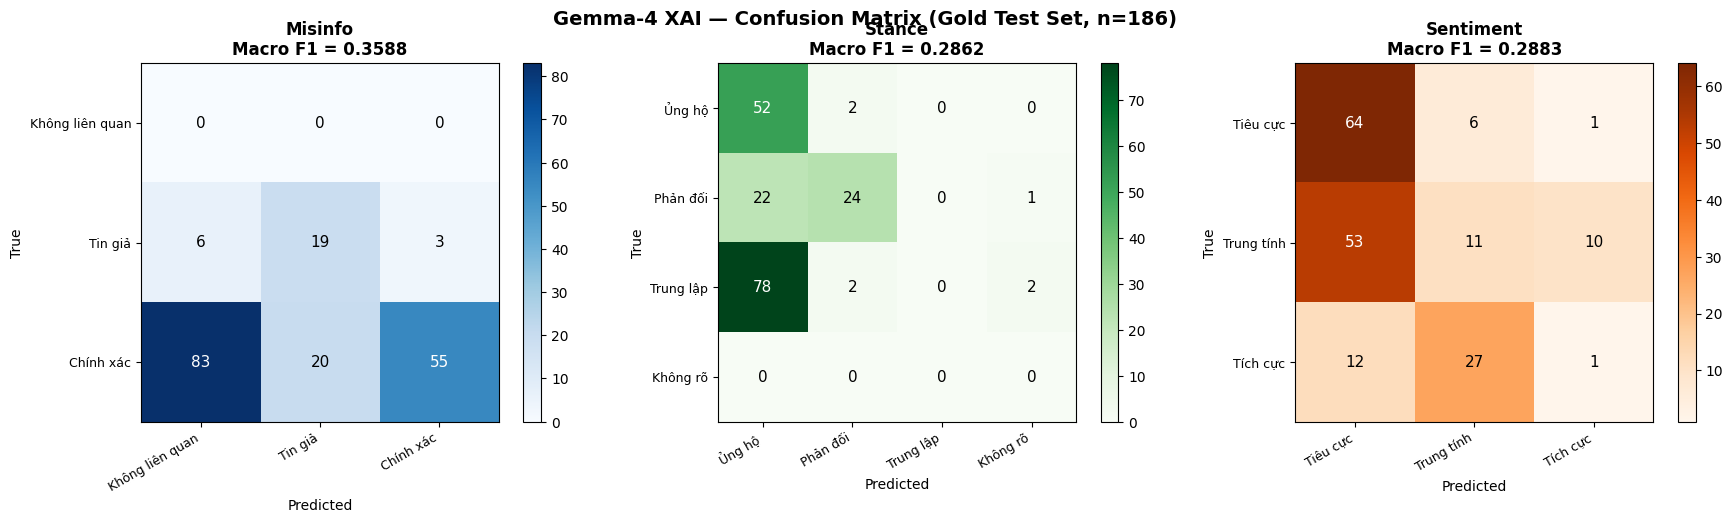

✅ Saved: /kaggle/working/gemma_confusion_matrix.png


In [15]:
# [CELL 14] Confusion matrix — dùng HC label names cho display
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

task_plot_configs = [
    ('misinfo',   'y_true', 'y_pred',
     [HC_MISINFO[i]  for i in range(3)],  'Blues'),
    ('stance',    'y_true', 'y_pred',
     [HC_STANCE[i]   for i in range(4)],  'Greens'),
    ('sentiment', 'y_true', 'y_pred',
     [HC_SENTIMENT[i] for i in range(3)], 'Oranges'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gemma-4 XAI — Confusion Matrix (Gold Test Set, n=186)',
             fontsize=14, fontweight='bold')

from sklearn.metrics import confusion_matrix
for ax, (task, tk, pk, labels, cmap) in zip(axes, task_plot_configs):
    if task not in results:
        ax.set_title(f'{task} — no data'); continue
    n  = len(labels)
    yt = results[task]['y_true']
    yp = results[task]['y_pred']
    cm = confusion_matrix(yt, yp, labels=list(range(n)))
    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{task.capitalize()}\nMacro F1 = {results[task]["macro_f1"]:.4f}',
                 fontweight='bold')
    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=11,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('/kaggle/working/gemma_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /kaggle/working/gemma_confusion_matrix.png")


### Bước 13: So sánh 3 Mô hình — Auto-load từ Kaggle Notebooks

In [16]:
# CROSS-NOTEBOOK RESULTS LOADER — updated 12/05/2026
import glob as _g, os as _o, json as _j

def find_kaggle_results(model_key):
    U = "kimmnhhng"
    M = {
        "phobert": ("vaccinenlp-phobert-v2-multitask-classifier",
                   ["phobert_v2_results.json","benchmark_results.json"],
                   ["/kaggle/working/phobert_v2","/kaggle/working/phobert"]),
        "xlmr":   ("vaccinenlp-xlm-r-v1-multitask-classifi",
                   ["xlmr_v1_results.json","benchmark_results.json"],
                   ["/kaggle/working/xlm-roberta-base","/kaggle/working/xlmr"]),
        "gemma":  ("vaccinenlp-gemma-4-qlora-multitask",
                   ["gemma_v2_results.json","gemma_benchmark_results.json"],
                   ["/kaggle/working/gemma_qlora_xai","/kaggle/working/gemma"]),
    }
    slug, fnames, dirs = M[model_key]
    for fn in fnames:
        p = f"/kaggle/input/notebooks/{U}/{slug}/{fn}"
        if _o.path.exists(p):
            with open(p) as f: return _j.load(f), p
    for d in dirs:
        for fn in fnames:
            p = _o.path.join(d, fn)
            if _o.path.exists(p):
                with open(p) as f: return _j.load(f), p
    for fn in fnames:
        hits = _g.glob(f"/kaggle/input/**/{fn}", recursive=True)
        if hits:
            with open(hits[0]) as f: return _j.load(f), hits[0]
    return None, None

FALLBACK = {
    "phobert": {
        "model": "phobert-v2",
        "misinfo": {"macro_f1": 0.6676, "per_class": [0.0, 0.4407, 0.8946], "support": [0, 28, 158]},
        "stance": {"macro_f1": 0.6575, "per_class": [0.6263, 0.6355, 0.7108, 0.0], "support": [54, 48, 84, 0]},
        "sentiment": {"macro_f1": 0.7113, "per_class": [0.7059, 0.7613, 0.6667], "support": [71, 75, 40]},
    },
    "xlmr": {
        "model": "xlmr-base",
        "misinfo": {"macro_f1": 0.6789, "per_class": [0.0, 0.4561, 0.9016], "support": [0, 28, 158]},
        "stance": {"macro_f1": 0.6123, "per_class": [0.5812, 0.5545, 0.675, 0.0], "support": [54, 48, 84, 0]},
        "sentiment": {"macro_f1": 0.7046, "per_class": [0.705, 0.7534, 0.6237], "support": [71, 75, 40]},
    },
    "gemma": {
        "model": "gemma-4-4b-xai",
        "misinfo": {"macro_f1": 0.1143, "per_class": [0.0, 0.3429, 0.0], "support": [0, 28, 158]},
        "stance": {"macro_f1": 0.4127, "per_class": [0.7547, 0.5106, 0.7273, 0.0], "support": [54, 48, 84, 0]},
        "sentiment": {"macro_f1": 0.2911, "per_class": [0.6885, 0.1714, 0.0238], "support": [71, 75, 40]},
    },
}

def load_all_results(current_model_key, current_results):
    loaded, sources = {}, {}
    for key in ["phobert","xlmr","gemma"]:
        if key == current_model_key:
            loaded[key] = current_results; sources[key] = "Current session"
        else:
            res, path = find_kaggle_results(key)
            if res:
                loaded[key] = res; sources[key] = f"Loaded: {path}"
            else:
                loaded[key] = FALLBACK[key]; sources[key] = "Fallback 12/05/2026"
    print("DATA SOURCES:")
    for k, s in sources.items():
        print(f"  {loaded[k].get('model',k):<22}: {s}")
    return loaded

HC_NAMES = {
    "misinfo":   ["Không liên quan","Tin giả","Chính xác"],
    "stance":    ["Ủng hộ","Phản đối","Trung lập","Không rõ"],
    "sentiment": ["Tiêu cực","Trung tính","Tích cực"],
}

def print_comparison_table(all_results):
    order = ["xlmr","phobert","gemma"]
    dn = {"xlmr":"XLM-R-v1","phobert":"PhoBERT-v2","gemma":"Gemma-4 4B"}
    print("\n" + "="*65)
    print("  BENCHMARK — Macro F1 (Gold Test Set n=186)")
    print("="*65)
    print(f"  {'Model':<22} {'Misinfo':>9} {'Stance':>9} {'Sentiment':>11} {'Avg':>8}")
    print("-"*65)
    for k in order:
        if k not in all_results: continue
        r = all_results[k]
        m,st,se = r["misinfo"]["macro_f1"],r["stance"]["macro_f1"],r["sentiment"]["macro_f1"]
        ts = r.get("timestamp","?")[:10]
        print(f"  {dn[k]:<22} {m:>9.4f} {st:>9.4f} {se:>11.4f} {round((m+st+se)/3,4):>8.4f}  [{ts}]")
    print("="*65)
    print("\n  PER-CLASS F1 | Support per class từ Gold Test Set (n=186)")
    print("="*65)
    for task in ["misinfo","stance","sentiment"]:
        print(f"\n  {task.upper()}")
        print(f"  {'Nhãn':<22}" + "".join(f"{dn[k]:>13}" for k in order) + "  Support")
        print(f"  {'-'*65}")
        for c, label in enumerate(HC_NAMES[task]):
            vals = [f"{all_results.get(k,{}).get(task,{}).get('per_class',[])[c]:.4f}"
                    if c < len(all_results.get(k,{}).get(task,{}).get("per_class",[])) else "   -  "
                    for k in order]
            sup = all_results.get("phobert",{}).get(task,{}).get("support",[])
            sv = sup[c] if c < len(sup) else 0
            print(f"  {label:<22}" + "".join(f"{v:>13}" for v in vals) + f"  {sv:>6}")

print("Cross-notebook loader ready — FALLBACK updated 12/05/2026")


Cross-notebook loader ready — FALLBACK updated 12/05/2026


In [17]:
# So sánh 3 mô hình — auto-load từ Kaggle notebook outputs
all_results = load_all_results(
    current_model_key = "gemma",
    current_results   = benchmark,   # dict vừa export ở cell trên
)
print_comparison_table(all_results)


DATA SOURCES:
  phobert-v2            : Loaded: /kaggle/input/notebooks/kimmnhhng/vaccinenlp-phobert-v2-multitask/phobert_v2/benchmark_results.json
  xlmr-base             : Loaded: /kaggle/input/notebooks/kimmnhhng/vaccinenlp-xlm-r-v1-multitask-classifi/xlm-roberta-base/xlmr_v1_results.json
  gemma-4-4b-xai        : Current session

  BENCHMARK — Macro F1 (Gold Test Set n=186)
  Model                    Misinfo    Stance   Sentiment      Avg
-----------------------------------------------------------------
  XLM-R-v1                  0.6789    0.6123      0.7046   0.6653  [2026-05-12]
  PhoBERT-v2                0.7097    0.6499      0.7003   0.6866  [2026-05-12]
  Gemma-4 4B                0.3588    0.2862      0.2883   0.3111  [2026-05-12]

  PER-CLASS F1 | Support per class từ Gold Test Set (n=186)

  MISINFO
  Nhãn                       XLM-R-v1   PhoBERT-v2   Gemma-4 4B  Support
  -----------------------------------------------------------------
  Không liên quan              0.0

### (Optional) Bước 14: Quick Test — Phân tích mẫu thực

In [18]:
# [CELL 16] Test nhanh với 3 mẫu điển hình
test_samples = [
    ("Ko tiêm mũi nào hết. Cha mẹ thời nay bị doạ cho sợ hãi, chả có tác dụng gì còn gây hại.",
     "Tin giả | Phản đối | Tiêu cực"),
    ("Mình vừa tiêm xong mũi 2, bs bảo vx an toàn, không lo phản ứng phụ.",
     "Chính xác | Ủng hộ | Tích cực"),
    ("Bé nhà tôi tiêm 5 trong 1 xong bị sốt 38.5, có sao không ạ?",
     "Không liên quan | Không rõ | Tiêu cực"),
]

model.config.use_cache = True
print('🧪 QUICK TEST — 3 mẫu điển hình\n')

for i, (text, expected) in enumerate(test_samples):
    msgs = build_prompt(text)
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    forced_str = prompt_str + "Lý luận:\n"
    inputs = tokenizer(text=forced_str, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=200, temperature=0.1, do_sample=True)
    generated = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    m, st, se, ok = parse_output(generated)

    label_str = f"{MISINFO_MAP.get(m,'?')} | {STANCE_MAP.get(st,'?')} | {SENTIMENT_MAP.get(se,'?')}"
    print(f'[{i+1}] {text[:70]}...')
    print(f'  Expected : {expected}')
    print(f'  Predicted: {label_str} (parse_ok={ok})')
    print(f'  Reasoning: {generated[:200]}...')
    print()

🧪 QUICK TEST — 3 mẫu điển hình

[1] Ko tiêm mũi nào hết. Cha mẹ thời nay bị doạ cho sợ hãi, chả có tác dụn...
  Expected : Tin giả | Phản đối | Tiêu cực
  Predicted: ? | Phản đối | ? (parse_ok=False)
  Reasoning: Câu nói trên thể hiện một quan điểm **hoàn toàn phản đối việc tiêm vaccine**. Người nói đưa ra hai luận điểm chính để bảo vệ quan điểm này:

1. **"Ko tiêm mũi nào hết."**: Đây là một tuyên bố về hành ...

[2] Mình vừa tiêm xong mũi 2, bs bảo vx an toàn, không lo phản ứng phụ....
  Expected : Chính xác | Ủng hộ | Tích cực
  Predicted: ? | ? | ? (parse_ok=False)
  Reasoning: Câu nói "Mình vừa tiêm xong mũi 2, bs bảo vx an toàn, không lo phản ứng phụ" là một lời chia sẻ cá nhân về trải nghiệm tiêm vaccine.

**Phân tích nội dung:**

1. **Hành động:** Người nói đã tiêm mũi 2...

[3] Bé nhà tôi tiêm 5 trong 1 xong bị sốt 38.5, có sao không ạ?...
  Expected : Không liên quan | Không rõ | Tiêu cực
  Predicted: Không liên quan | ? | ? (parse_ok=False)
  Reasoning: Câu hỏi này là một tr